In [1]:
# Check GPU availability

import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU is not available. Please enable GPU in Runtime settings.")

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [2]:
# Install required libraries

!pip install -q kagglehub scikit-learn pandas matplotlib seaborn tqdm xgboost thop

In [3]:
# Import required libraries

import os
import glob
import time
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC, LinearSVC

from xgboost import XGBClassifier

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cuda


In [4]:
# Download the ISIC skin cancer dataset

import kagglehub

path = kagglehub.dataset_download(
    "nodoubttome/skin-cancer9-classesisic"
)

print("Dataset path:")
print(path)

100%|██████████| 786M/786M [00:43<00:00, 18.9MB/s]

Extracting files...


Dataset path:
/root/.cache/kagglehub/datasets/nodoubttome/skin-cancer9-classesisic/versions/1


In [5]:
# Display folders and files inside the downloaded dataset

for root, dirs, files in os.walk(path):
    level = root.replace(path, '').count(os.sep)

    if level <= 2:
        print("  " * level + os.path.basename(root) + "/")

1/
  Skin cancer ISIC The International Skin Imaging Collaboration/
    Train/
    Test/


In [6]:
# Find image files

image_extensions = ["*.jpg", "*.jpeg", "*.png", "*.JPG", "*.JPEG", "*.PNG"]

image_files = []

for ext in image_extensions:
    image_files.extend(glob.glob(os.path.join(path, "**", ext), recursive=True))

print("Total image files found:", len(image_files))

print("\nFirst 10 images:")
for img in image_files[:10]:
    print(img)

Total image files found: 2357

First 10 images:
/root/.cache/kagglehub/datasets/nodoubttome/skin-cancer9-classesisic/versions/1/Skin cancer ISIC The International Skin Imaging Collaboration/Train/squamous cell carcinoma/ISIC_0033295.jpg
/root/.cache/kagglehub/datasets/nodoubttome/skin-cancer9-classesisic/versions/1/Skin cancer ISIC The International Skin Imaging Collaboration/Train/squamous cell carcinoma/ISIC_0029582.jpg
/root/.cache/kagglehub/datasets/nodoubttome/skin-cancer9-classesisic/versions/1/Skin cancer ISIC The International Skin Imaging Collaboration/Train/squamous cell carcinoma/ISIC_0025069.jpg
/root/.cache/kagglehub/datasets/nodoubttome/skin-cancer9-classesisic/versions/1/Skin cancer ISIC The International Skin Imaging Collaboration/Train/squamous cell carcinoma/ISIC_0029638.jpg
/root/.cache/kagglehub/datasets/nodoubttome/skin-cancer9-classesisic/versions/1/Skin cancer ISIC The International Skin Imaging Collaboration/Train/squamous cell carcinoma/ISIC_0025247.jpg
/root/.

In [7]:
# Look for directories that may represent the dataset classes

all_dirs = []

for root, dirs, files in os.walk(path):
    for d in dirs:
        all_dirs.append(os.path.join(root, d))

print("Directories:")
for d in all_dirs:
    print(d)

Directories:
/root/.cache/kagglehub/datasets/nodoubttome/skin-cancer9-classesisic/versions/1/Skin cancer ISIC The International Skin Imaging Collaboration
/root/.cache/kagglehub/datasets/nodoubttome/skin-cancer9-classesisic/versions/1/Skin cancer ISIC The International Skin Imaging Collaboration/Train
/root/.cache/kagglehub/datasets/nodoubttome/skin-cancer9-classesisic/versions/1/Skin cancer ISIC The International Skin Imaging Collaboration/Test
/root/.cache/kagglehub/datasets/nodoubttome/skin-cancer9-classesisic/versions/1/Skin cancer ISIC The International Skin Imaging Collaboration/Train/squamous cell carcinoma
/root/.cache/kagglehub/datasets/nodoubttome/skin-cancer9-classesisic/versions/1/Skin cancer ISIC The International Skin Imaging Collaboration/Train/pigmented benign keratosis
/root/.cache/kagglehub/datasets/nodoubttome/skin-cancer9-classesisic/versions/1/Skin cancer ISIC The International Skin Imaging Collaboration/Train/actinic keratosis
/root/.cache/kagglehub/datasets/nodou

In [8]:
# Create a dataframe of image paths and class labels

records = []

for img_path in image_files:
    relative_path = os.path.relpath(img_path, path)
    parts = relative_path.split(os.sep)

    # The first directory containing the image is treated as its class
    if len(parts) >= 2:
        label = parts[0]
    else:
        label = "unknown"

    records.append({
        "image_path": img_path,
        "label": label
    })

df = pd.DataFrame(records)

print("Total images:", len(df))
print("\nClasses:")
print(df["label"].value_counts())

Total images: 2357

Classes:
label
Skin cancer ISIC The International Skin Imaging Collaboration    2357
Name: count, dtype: int64


In [9]:
# Count images in every class

class_counts = df["label"].value_counts().sort_index()

print(class_counts)

label
Skin cancer ISIC The International Skin Imaging Collaboration    2357
Name: count, dtype: int64


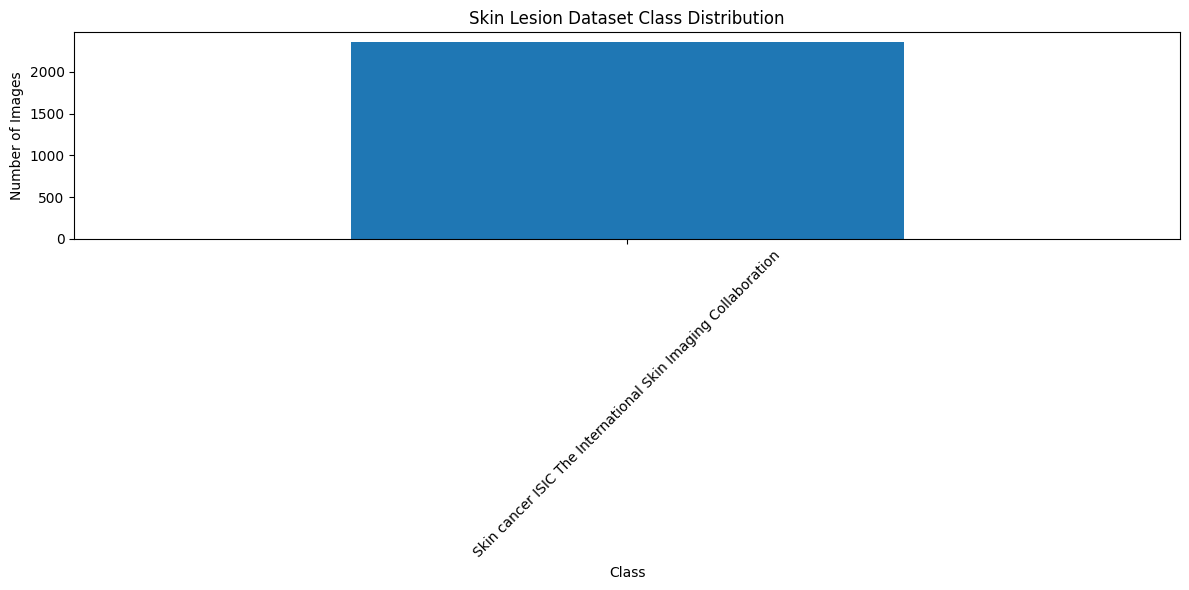

In [10]:
# Visualize class distribution

plt.figure(figsize=(12, 6))

class_counts.plot(kind="bar")

plt.title("Skin Lesion Dataset Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [15]:
# Check the actual dataset folder structure

print("Dataset path:")
print(path)

print("\nFolders and number of files:")

for root, dirs, files in os.walk(path):
    image_count = sum(
        1 for f in files
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    )

    if image_count > 0:
        print(f"{root}  -->  {image_count} images")

Dataset path:
/root/.cache/kagglehub/datasets/nodoubttome/skin-cancer9-classesisic/versions/1

Folders and number of files:
/root/.cache/kagglehub/datasets/nodoubttome/skin-cancer9-classesisic/versions/1/Skin cancer ISIC The International Skin Imaging Collaboration/Train/squamous cell carcinoma  -->  181 images
/root/.cache/kagglehub/datasets/nodoubttome/skin-cancer9-classesisic/versions/1/Skin cancer ISIC The International Skin Imaging Collaboration/Train/pigmented benign keratosis  -->  462 images
/root/.cache/kagglehub/datasets/nodoubttome/skin-cancer9-classesisic/versions/1/Skin cancer ISIC The International Skin Imaging Collaboration/Train/actinic keratosis  -->  114 images
/root/.cache/kagglehub/datasets/nodoubttome/skin-cancer9-classesisic/versions/1/Skin cancer ISIC The International Skin Imaging Collaboration/Train/vascular lesion  -->  139 images
/root/.cache/kagglehub/datasets/nodoubttome/skin-cancer9-classesisic/versions/1/Skin cancer ISIC The International Skin Imaging Col

In [16]:
# Find all folders that contain images
# This will help us identify the 9 skin lesion classes

class_folders = []

for root, dirs, files in os.walk(path):

    image_count = sum(
        1 for f in files
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    )

    if image_count > 0:
        class_folders.append((root, image_count))

print("Number of image-containing folders:", len(class_folders))

for folder, count in class_folders:
    print(f"{os.path.basename(folder)} --> {count} images")

Number of image-containing folders: 18
squamous cell carcinoma --> 181 images
pigmented benign keratosis --> 462 images
actinic keratosis --> 114 images
vascular lesion --> 139 images
melanoma --> 438 images
nevus --> 357 images
basal cell carcinoma --> 376 images
dermatofibroma --> 95 images
seborrheic keratosis --> 77 images
squamous cell carcinoma --> 16 images
pigmented benign keratosis --> 16 images
actinic keratosis --> 16 images
vascular lesion --> 3 images
melanoma --> 16 images
nevus --> 16 images
basal cell carcinoma --> 16 images
dermatofibroma --> 16 images
seborrheic keratosis --> 3 images


In [17]:
# Create DataFrame with correct class labels

records = []

for folder, image_count in class_folders:

    # The folder name is the class name
    class_name = os.path.basename(folder)

    # Find images inside this class folder
    for ext in ["*.jpg", "*.jpeg", "*.png", "*.JPG", "*.JPEG", "*.PNG"]:

        images_in_folder = glob.glob(
            os.path.join(folder, ext)
        )

        for img_path in images_in_folder:
            records.append({
                "image_path": img_path,
                "label": class_name
            })

df = pd.DataFrame(records)

print("Total images:", len(df))
print("Number of classes:", df["label"].nunique())

print("\nClasses:")
for class_name in sorted(df["label"].unique()):
    print("-", class_name)

Total images: 2357
Number of classes: 9

Classes:
- actinic keratosis
- basal cell carcinoma
- dermatofibroma
- melanoma
- nevus
- pigmented benign keratosis
- seborrheic keratosis
- squamous cell carcinoma
- vascular lesion


In [18]:
# Check number of images in each class

class_distribution = df["label"].value_counts().sort_index()

print("Class distribution:")
print(class_distribution)

Class distribution:
label
actinic keratosis             130
basal cell carcinoma          392
dermatofibroma                111
melanoma                      454
nevus                         373
pigmented benign keratosis    478
seborrheic keratosis           80
squamous cell carcinoma       197
vascular lesion               142
Name: count, dtype: int64


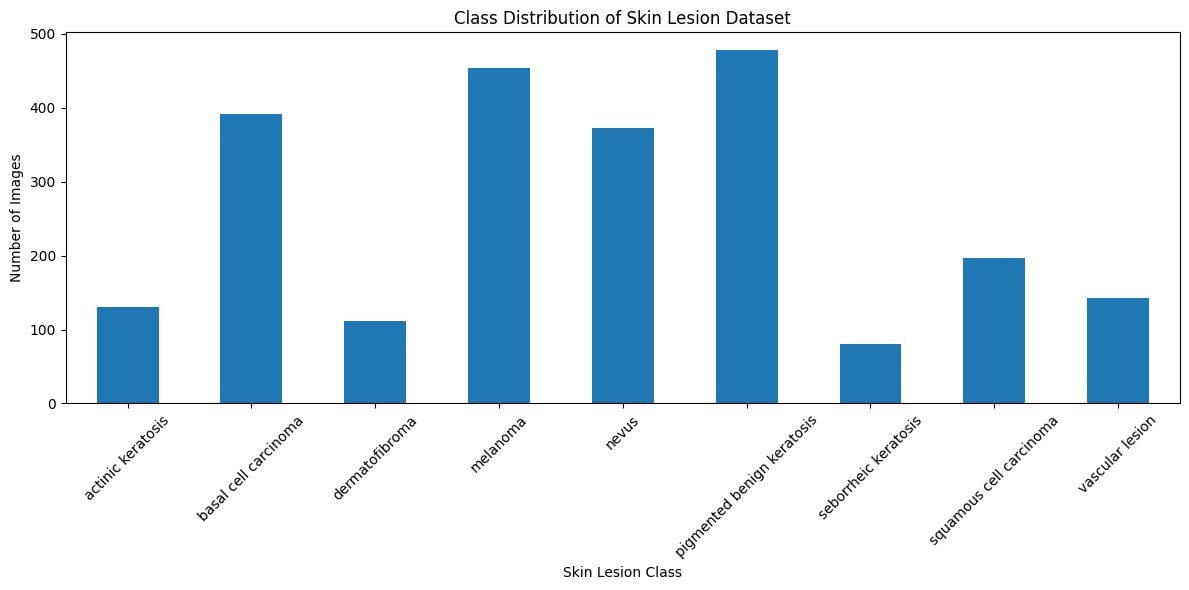

In [19]:
# Visualize class distribution

plt.figure(figsize=(12, 6))

df["label"].value_counts().sort_index().plot(
    kind="bar"
)

plt.xlabel("Skin Lesion Class")
plt.ylabel("Number of Images")
plt.title("Class Distribution of Skin Lesion Dataset")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Classes: ['actinic keratosis', 'basal cell carcinoma', 'dermatofibroma', 'melanoma', 'nevus', 'pigmented benign keratosis', 'seborrheic keratosis', 'squamous cell carcinoma', 'vascular lesion']
Number of classes: 9


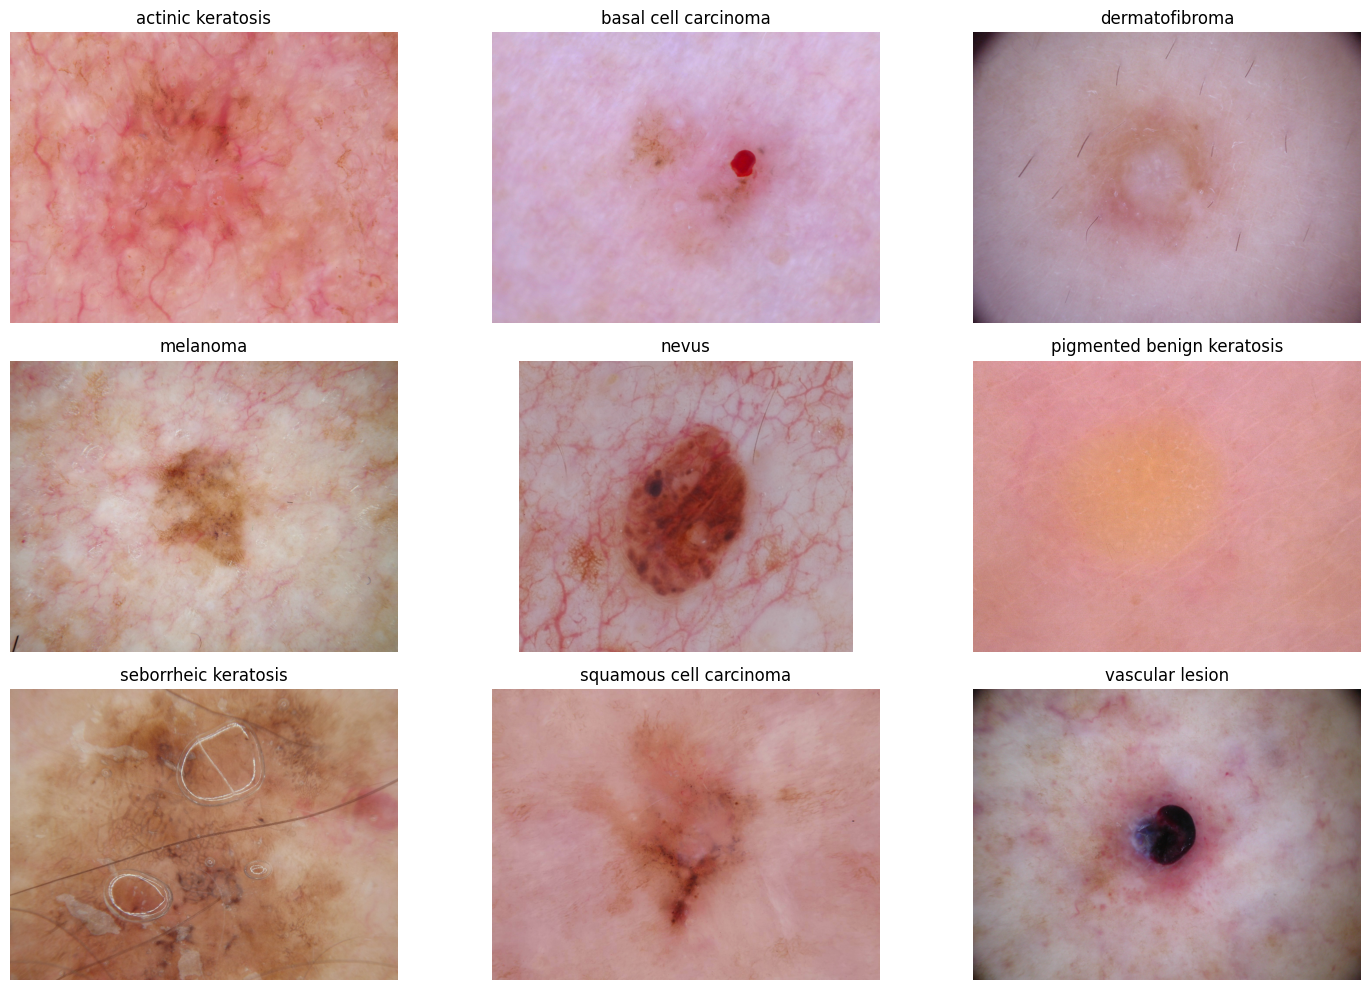

In [20]:
# Display one sample image from each of the 9 classes

classes = sorted(df["label"].unique())

print("Classes:", classes)
print("Number of classes:", len(classes))

plt.figure(figsize=(15, 10))

for i, class_name in enumerate(classes):

    # Select one image from this class
    sample = df[
        df["label"] == class_name
    ].sample(
        1,
        random_state=42
    ).iloc[0]

    # Open image
    image = Image.open(
        sample["image_path"]
    ).convert("RGB")

    # Display image
    plt.subplot(3, 3, i + 1)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()


In [21]:
# Convert class names into numerical labels

classes = sorted(df["label"].unique())

class_to_idx = {
    class_name: idx
    for idx, class_name in enumerate(classes)
}

idx_to_class = {
    idx: class_name
    for class_name, idx in class_to_idx.items()
}

df["label_id"] = df["label"].map(class_to_idx)

num_classes = len(classes)

print("Class mapping:")

for idx, class_name in idx_to_class.items():
    print(idx, "=", class_name)

print("\nNumber of classes:", num_classes)

Class mapping:
0 = actinic keratosis
1 = basal cell carcinoma
2 = dermatofibroma
3 = melanoma
4 = nevus
5 = pigmented benign keratosis
6 = seborrheic keratosis
7 = squamous cell carcinoma
8 = vascular lesion

Number of classes: 9


In [22]:
# Verify labels and dataset

print("Total images:", len(df))

print(
    "Missing labels:",
    df["label_id"].isna().sum()
)

print("\nLabel distribution:")

print(
    df["label_id"]
    .value_counts()
    .sort_index()
)

Total images: 2357
Missing labels: 0

Label distribution:
label_id
0    130
1    392
2    111
3    454
4    373
5    478
6     80
7    197
8    142
Name: count, dtype: int64


In [23]:
# Split dataset into training, validation and testing sets

train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df["label_id"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label_id"],
    random_state=42
)

print("Training images:", len(train_df))
print("Validation images:", len(val_df))
print("Testing images:", len(test_df))

print(
    "\nTotal:",
    len(train_df) +
    len(val_df) +
    len(test_df)
)

Training images: 1885
Validation images: 236
Testing images: 236

Total: 2357


In [24]:
# Check class distribution in each dataset split

print("========== TRAINING ==========")
print(
    train_df["label"]
    .value_counts()
    .sort_index()
)

print("\n========== VALIDATION ==========")
print(
    val_df["label"]
    .value_counts()
    .sort_index()
)

print("\n========== TESTING ==========")
print(
    test_df["label"]
    .value_counts()
    .sort_index()
)

========== TRAINING ==========
label
actinic keratosis             104
basal cell carcinoma          313
dermatofibroma                 89
melanoma                      363
nevus                         298
pigmented benign keratosis    382
seborrheic keratosis           64
squamous cell carcinoma       158
vascular lesion               114
Name: count, dtype: int64

========== VALIDATION ==========
label
actinic keratosis             13
basal cell carcinoma          39
dermatofibroma                11
melanoma                      46
nevus                         37
pigmented benign keratosis    48
seborrheic keratosis           8
squamous cell carcinoma       20
vascular lesion               14
Name: count, dtype: int64

========== TESTING ==========
label
actinic keratosis             13
basal cell carcinoma          40
dermatofibroma                11
melanoma                      45
nevus                         38
pigmented benign keratosis    48
seborrheic keratosis           8


In [25]:
# Set image size

IMG_SIZE = 224

print(
    "Image size:",
    IMG_SIZE,
    "x",
    IMG_SIZE
)

Image size: 224 x 224


In [26]:
# Define image preprocessing and augmentation

train_transform = transforms.Compose([

    # Resize image
    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    # Random horizontal flip
    transforms.RandomHorizontalFlip(p=0.5),

    # Random vertical flip
    transforms.RandomVerticalFlip(p=0.5),

    # Random rotation, translation, scaling and shearing
    transforms.RandomAffine(
        degrees=15,
        translate=(0.2, 0.2),
        scale=(0.8, 1.2),
        shear=10
    ),

    # Convert image to tensor
    transforms.ToTensor(),

    # Normalize using ImageNet statistics
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# Validation and testing preprocessing

val_test_transform = transforms.Compose([

    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [27]:
# Create custom PyTorch Dataset

class SkinLesionDataset(Dataset):

    def __init__(self, dataframe, transform=None):

        self.dataframe = dataframe.reset_index(
            drop=True
        )

        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):

        row = self.dataframe.iloc[idx]

        # Load image
        image = Image.open(
            row["image_path"]
        ).convert("RGB")

        # Get numerical label
        label = int(row["label_id"])

        # Apply transformation
        if self.transform:
            image = self.transform(image)

        return image, label

In [28]:
# Create PyTorch datasets

train_dataset = SkinLesionDataset(
    train_df,
    transform=train_transform
)

val_dataset = SkinLesionDataset(
    val_df,
    transform=val_test_transform
)

test_dataset = SkinLesionDataset(
    test_df,
    transform=val_test_transform
)

print("Train dataset:", len(train_dataset))
print("Validation dataset:", len(val_dataset))
print("Test dataset:", len(test_dataset))

Train dataset: 1885
Validation dataset: 236
Test dataset: 236


In [29]:
# Create DataLoaders

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 59
Validation batches: 8
Test batches: 8


In [30]:
# Check one batch of images

images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

print("\nLabels in first batch:")
print(labels)

Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])

Labels in first batch:
tensor([7, 5, 4, 1, 5, 1, 1, 7, 8, 7, 3, 4, 2, 1, 1, 3, 5, 2, 5, 4, 0, 4, 3, 5,
        7, 5, 4, 6, 3, 6, 1, 8])


In [31]:
# Confirm GPU availability

print("Device:", device)

if torch.cuda.is_available():

    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

    print(
        "GPU memory allocated:",
        round(
            torch.cuda.memory_allocated() / 1024**3,
            2
        ),
        "GB"
    )

else:
    print("WARNING: GPU is not available.")

Device: cuda
GPU: Tesla T4
GPU memory allocated: 0.0 GB


In [32]:
# Function to create pretrained CNN models

def create_model(model_name, num_classes):

    if model_name == "AlexNet":

        model = models.alexnet(
            weights=models.AlexNet_Weights.DEFAULT
        )

        model.classifier[6] = nn.Linear(
            model.classifier[6].in_features,
            num_classes
        )


    elif model_name == "VGG16":

        model = models.vgg16(
            weights=models.VGG16_Weights.DEFAULT
        )

        model.classifier[6] = nn.Linear(
            model.classifier[6].in_features,
            num_classes
        )


    elif model_name == "VGG19":

        model = models.vgg19(
            weights=models.VGG19_Weights.DEFAULT
        )

        model.classifier[6] = nn.Linear(
            model.classifier[6].in_features,
            num_classes
        )


    elif model_name == "ResNet18":

        model = models.resnet18(
            weights=models.ResNet18_Weights.DEFAULT
        )

        model.fc = nn.Linear(
            model.fc.in_features,
            num_classes
        )


    elif model_name == "ResNet50":

        model = models.resnet50(
            weights=models.ResNet50_Weights.DEFAULT
        )

        model.fc = nn.Linear(
            model.fc.in_features,
            num_classes
        )


    elif model_name == "ResNet101":

        model = models.resnet101(
            weights=models.ResNet101_Weights.DEFAULT
        )

        model.fc = nn.Linear(
            model.fc.in_features,
            num_classes
        )


    elif model_name == "DenseNet121":

        model = models.densenet121(
            weights=models.DenseNet121_Weights.DEFAULT
        )

        model.classifier = nn.Linear(
            model.classifier.in_features,
            num_classes
        )


    elif model_name == "EfficientNet-B0":

        model = models.efficientnet_b0(
            weights=models.EfficientNet_B0_Weights.DEFAULT
        )

        model.classifier[1] = nn.Linear(
            model.classifier[1].in_features,
            num_classes
        )


    else:
        raise ValueError(
            "Unknown model: " + model_name
        )

    return model

In [33]:
# List CNN models for comparison

model_names = [
    "AlexNet",
    "VGG16",
    "VGG19",
    "ResNet18",
    "ResNet50",
    "ResNet101",
    "DenseNet121",
    "EfficientNet-B0"
]

print("Models to train:")

for model_name in model_names:
    print("-", model_name)

Models to train:
- AlexNet
- VGG16
- VGG19
- ResNet18
- ResNet50
- ResNet101
- DenseNet121
- EfficientNet-B0


In [34]:
# Test ResNet18 model

test_model = create_model(
    "ResNet18",
    num_classes
)

print(test_model)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 116MB/s]

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [35]:
# Move model to GPU

test_model = test_model.to(device)

print(
    "Model is running on:",
    next(test_model.parameters()).device
)

Model is running on: cuda:0


In [36]:
# Function for training a CNN model

def train_model(
    model,
    train_loader,
    val_loader,
    epochs=5,
    lr=1e-4
):

    model = model.to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=lr
    )

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.1,
        patience=2
    )

    best_val_acc = 0.0

    best_weights = copy.deepcopy(
        model.state_dict()
    )

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    for epoch in range(epochs):

        # ==========================
        # TRAINING
        # ==========================

        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        progress = tqdm(
            train_loader,
            desc=f"Epoch {epoch+1}/{epochs}"
        )

        for images, labels in progress:

            images = images.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            loss.backward()

            optimizer.step()

            running_loss += (
                loss.item() *
                images.size(0)
            )

            _, predicted = torch.max(
                outputs,
                1
            )

            total += labels.size(0)

            correct += (
                predicted == labels
            ).sum().item()

            progress.set_postfix(
                loss=loss.item()
            )

        train_loss = (
            running_loss / total
        )

        train_acc = (
            correct / total
        )


        # ==========================
        # VALIDATION
        # ==========================

        model.eval()

        val_loss_total = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(
                    device,
                    non_blocking=True
                )

                labels = labels.to(
                    device,
                    non_blocking=True
                )

                outputs = model(images)

                loss = criterion(
                    outputs,
                    labels
                )

                val_loss_total += (
                    loss.item() *
                    images.size(0)
                )

                _, predicted = torch.max(
                    outputs,
                    1
                )

                val_total += labels.size(0)

                val_correct += (
                    predicted == labels
                ).sum().item()


        val_loss = (
            val_loss_total / val_total
        )

        val_acc = (
            val_correct / val_total
        )

        scheduler.step(val_loss)


        # Save history

        history["train_loss"].append(
            train_loss
        )

        history["train_acc"].append(
            train_acc
        )

        history["val_loss"].append(
            val_loss
        )

        history["val_acc"].append(
            val_acc
        )


        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f}"
        )


        # Save best model

        if val_acc > best_val_acc:

            best_val_acc = val_acc

            best_weights = copy.deepcopy(
                model.state_dict()
            )


    # Load best weights

    model.load_state_dict(
        best_weights
    )

    return model, history

In [37]:
# Function to evaluate a trained CNN

def evaluate_model(model, loader):

    model.eval()

    all_labels = []
    all_predictions = []
    all_probabilities = []

    with torch.no_grad():

        for images, labels in tqdm(
            loader,
            desc="Evaluating"
        ):

            images = images.to(
                device,
                non_blocking=True
            )

            outputs = model(images)

            probabilities = torch.softmax(
                outputs,
                dim=1
            )

            predictions = torch.argmax(
                probabilities,
                dim=1
            )

            all_labels.extend(
                labels.numpy()
            )

            all_predictions.extend(
                predictions.cpu().numpy()
            )

            all_probabilities.extend(
                probabilities.cpu().numpy()
            )


    y_true = np.array(
        all_labels
    )

    y_pred = np.array(
        all_predictions
    )

    y_prob = np.array(
        all_probabilities
    )


    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )


    try:

        auc = roc_auc_score(
            y_true,
            y_prob,
            multi_class="ovr",
            average="weighted"
        )

    except:

        auc = np.nan


    metrics = {

        "Accuracy (%)":
            accuracy * 100,

        "Precision (%)":
            precision * 100,

        "Recall (%)":
            recall * 100,

        "F1-Score (%)":
            f1 * 100,

        "AUC (%)":
            auc * 100
    }


    return (
        metrics,
        y_true,
        y_pred,
        y_prob
    )

In [38]:
Train ResNet18 as a test

model = create_model(
    "ResNet18",
    num_classes
)

model, history = train_model(
    model,
    train_loader,
    val_loader,
    epochs=5,
    lr=1e-4
)

Epoch 1/5:   0%|          | 0/59 [00:00<?, ?it/s]

Epoch 1/5 | Train Loss: 1.4848 | Train Acc: 0.4912 | Val Loss: 1.1343 | Val Acc: 0.6186


Epoch 2/5:   0%|          | 0/59 [00:00<?, ?it/s]

Epoch 2/5 | Train Loss: 0.9285 | Train Acc: 0.6796 | Val Loss: 1.0329 | Val Acc: 0.6144


Epoch 3/5:   0%|          | 0/59 [00:00<?, ?it/s]

...

Epoch 4/5:   0%|          | 0/59 [00:00<?, ?it/s]

Epoch 4/5 | Train Loss: 0.7411 | Train Acc: 0.7279 | Val Loss: 0.8864 | Val Acc: 0.6695


Epoch 5/5:   0%|          | 0/59 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c2afaa2e0c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c2afaa2e0c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/

Epoch 5/5 | Train Loss: 0.6401 | Train Acc: 0.7576 | Val Loss: 0.8719 | Val Acc: 0.6737


In [39]:
# Evaluate ResNet18 on the test dataset

metrics, y_true, y_pred, y_prob = evaluate_model(
    model,
    test_loader
)

print("\n========== ResNet18 Results ==========")

for metric, value in metrics.items():
    print(
        f"{metric}: {value:.2f}"
    )

Evaluating:   0%|          | 0/8 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c2afaa2e0c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c2afaa2e0c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/


========== ResNet18 Results ==========
Accuracy (%): 75.00
Precision (%): 74.66
Recall (%): 75.00
F1-Score (%): 73.55
AUC (%): 96.33


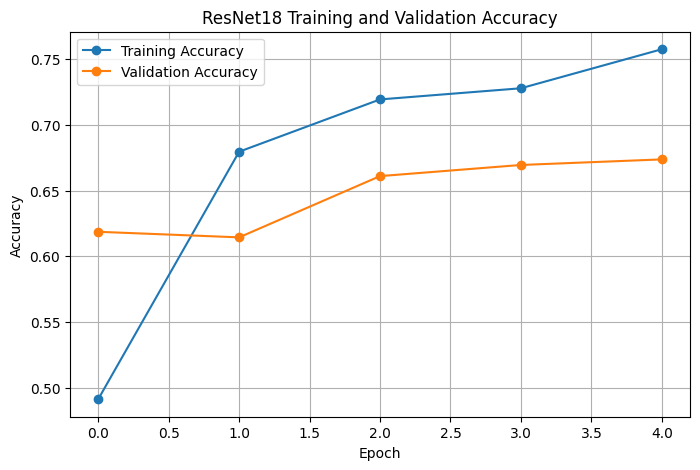

In [40]:
# Plot training and validation accuracy

plt.figure(figsize=(8, 5))

plt.plot(
    history["train_acc"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    history["val_acc"],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "ResNet18 Training and Validation Accuracy"
)

plt.legend()
plt.grid()

plt.show()

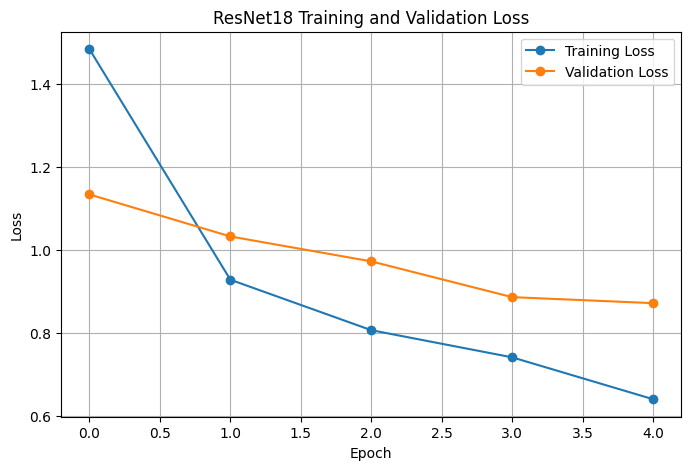

In [41]:
# Plot training and validation loss

plt.figure(figsize=(8, 5))

plt.plot(
    history["train_loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "ResNet18 Training and Validation Loss"
)

plt.legend()
plt.grid()

plt.show()

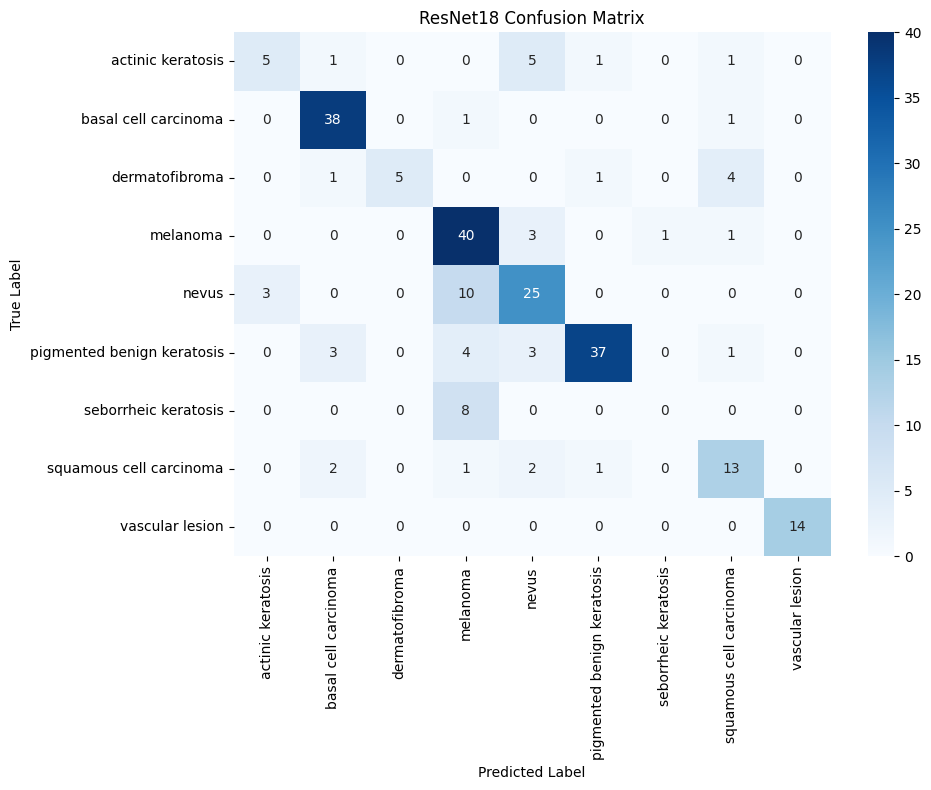

In [42]:
# Create confusion matrix

cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.title(
    "ResNet18 Confusion Matrix"
)

plt.tight_layout()
plt.show()

In [44]:
# Detailed classification report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=classes,
        zero_division=0
    )
)

                            precision    recall  f1-score   support

         actinic keratosis       0.62      0.38      0.48        13
      basal cell carcinoma       0.84      0.95      0.89        40
            dermatofibroma       1.00      0.45      0.62        11
                  melanoma       0.62      0.89      0.73        45
                     nevus       0.66      0.66      0.66        38
pigmented benign keratosis       0.93      0.77      0.84        48
      seborrheic keratosis       0.00      0.00      0.00         8
   squamous cell carcinoma       0.62      0.68      0.65        19
           vascular lesion       1.00      1.00      1.00        14

                  accuracy                           0.75       236
                 macro avg       0.70      0.64      0.65       236
              weighted avg       0.75      0.75      0.74       236



In [49]:
import gc

# Clear temporary model from GPU memory

if 'model' in locals() and model is not None:
    del model


torch.cuda.empty_cache()
gc.collect()

print("GPU cache cleared.")

GPU cache cleared.


In [50]:
# Train all CNN models

table1_results = []

trained_models = {}

histories = {}


for model_name in model_names:

    print("\n")
    print("=" * 70)
    print("TRAINING:", model_name)
    print("=" * 70)


    # Create model
    model = create_model(
        model_name,
        num_classes
    )


    # Train model
    model, history = train_model(
        model,
        train_loader,
        val_loader,
        epochs=5,
        lr=1e-4
    )


    # Evaluate model
    metrics, y_true_model, y_pred_model, y_prob_model = evaluate_model(
        model,
        test_loader
    )


    # Store results
    result = {
        "Model": model_name,
        **metrics
    }

    table1_results.append(
        result
    )


    # Save trained model
    trained_models[
        model_name
    ] = model


    # Save training history
    histories[
        model_name
    ] = history


    print(
        "\nResults for",
        model_name
    )

    for key, value in metrics.items():

        print(
            f"{key}: {value:.2f}"
        )


    # Clear unused GPU cache
    torch.cuda.empty_cache()



TRAINING: AlexNet
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:02<00:00, 106MB/s]


Epoch 1/5:   0%|          | 0/59 [00:00<?, ?it/s]

Epoch 1/5 | Train Loss: 1.6719 | Train Acc: 0.4005 | Val Loss: 1.4231 | Val Acc: 0.4873


Epoch 2/5:   0%|          | 0/59 [00:00<?, ?it/s]

...

Epoch 5/5:   0%|          | 0/59 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c2afaa2e0c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c2afaa2e0c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/

Epoch 5/5 | Train Loss: 0.7899 | Train Acc: 0.7247 | Val Loss: 0.8787 | Val Acc: 0.6610


Evaluating:   0%|          | 0/8 [00:00<?, ?it/s]


Results for EfficientNet-B0
Accuracy (%): 75.00
Precision (%): 73.43
Recall (%): 75.00
F1-Score (%): 73.03
AUC (%): 96.21


In [51]:
# Create Table 1

table1 = pd.DataFrame(
    table1_results
)

display(table1)

,Model,Accuracy (%),Precision (%),Recall (%),F1-Score (%),AUC (%)
0,AlexNet,66.525424,67.686518,66.525424,64.272207,94.222377
1,VGG16,65.254237,64.133149,65.254237,62.501044,93.643556
2,VGG19,61.864407,56.036299,61.864407,55.707116,92.526398
3,ResNet18,78.389831,76.467549,78.389831,77.157768,95.999420
4,ResNet50,76.694915,74.730833,76.694915,75.428224,95.714962
5,ResNet101,70.762712,71.029369,70.762712,69.788072,95.028045
6,DenseNet121,73.305085,71.010995,73.305085,70.926764,96.140683
7,EfficientNet-B0,75.000000,73.430913,75.000000,73.032219,96.205637


In [52]:
# Save Table 1 as CSV

table1.to_csv(
    "Table_1_Transfer_Learning_Results.csv",
    index=False
)

print("Table 1 saved successfully.")

Table 1 saved successfully.


In [53]:
# Display Table 1

display(table1)

,Model,Accuracy (%),Precision (%),Recall (%),F1-Score (%),AUC (%)
0,AlexNet,66.525424,67.686518,66.525424,64.272207,94.222377
1,VGG16,65.254237,64.133149,65.254237,62.501044,93.643556
2,VGG19,61.864407,56.036299,61.864407,55.707116,92.526398
3,ResNet18,78.389831,76.467549,78.389831,77.157768,95.999420
4,ResNet50,76.694915,74.730833,76.694915,75.428224,95.714962
5,ResNet101,70.762712,71.029369,70.762712,69.788072,95.028045
6,DenseNet121,73.305085,71.010995,73.305085,70.926764,96.140683
7,EfficientNet-B0,75.000000,73.430913,75.000000,73.032219,96.205637


In [54]:
# Create DenseNet121 feature extractor

feature_model = models.densenet121(
    weights=models.DenseNet121_Weights.DEFAULT
)

# Remove the final classification layer
feature_model.classifier = nn.Identity()

# Move model to GPU
feature_model = feature_model.to(device)

# Evaluation mode
feature_model.eval()

print("DenseNet121 feature extractor ready.")

DenseNet121 feature extractor ready.


In [55]:
# Function to extract deep features

def extract_features(model, loader):

    model.eval()

    features = []
    labels = []

    with torch.no_grad():

        for images, batch_labels in tqdm(
            loader,
            desc="Extracting features"
        ):

            images = images.to(
                device,
                non_blocking=True
            )

            # Extract deep features
            batch_features = model(images)

            # Move features to CPU
            features.append(
                batch_features.cpu().numpy()
            )

            labels.append(
                batch_labels.numpy()
            )

    # Combine all batches
    features = np.concatenate(
        features,
        axis=0
    )

    labels = np.concatenate(
        labels,
        axis=0
    )

    return features, labels

In [56]:
# Extract DenseNet121 features from training data

train_features, train_labels = extract_features(
    feature_model,
    train_loader
)

print(
    "Training feature shape:",
    train_features.shape
)

Extracting features:   0%|          | 0/59 [00:00<?, ?it/s]

Training feature shape: (1885, 1024)


In [57]:
# Extract DenseNet121 features from testing data

test_features, test_labels = extract_features(
    feature_model,
    test_loader
)

print(
    "Testing feature shape:",
    test_features.shape
)

Extracting features:   0%|          | 0/8 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c2afaa2e0c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c2afaa2e0c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/

Testing feature shape: (236, 1024)


In [58]:
# Standardize the deep features

scaler = StandardScaler()

train_features_scaled = scaler.fit_transform(
    train_features
)

test_features_scaled = scaler.transform(
    test_features
)

print(
    "Scaled training features:",
    train_features_scaled.shape
)

print(
    "Scaled testing features:",
    test_features_scaled.shape
)

Scaled training features: (1885, 1024)
Scaled testing features: (236, 1024)


In [59]:
# Define classical machine-learning classifiers

classifiers = {

    "Logistic Regression":
        LogisticRegression(
            max_iter=1000
        ),


    "Decision Tree":
        DecisionTreeClassifier(
            random_state=42
        ),


    "Random Forest":
        RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ),


    "K-Nearest Neighbors":
        KNeighborsClassifier(
            n_neighbors=5,
            n_jobs=-1
        ),


    "Linear SVM":
        SVC(
            kernel="linear",
            probability=True,
            random_state=42
        ),


    "RBF-SVM":
        SVC(
            kernel="rbf",
            probability=True,
            random_state=42
        ),


    "XGBoost":
        XGBClassifier(
            n_estimators=200,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="multi:softprob",
            num_class=num_classes,
            eval_metric="mlogloss",
            random_state=42,
            n_jobs=-1
        )
}

print("Classifiers created:")

for name in classifiers:
    print("-", name)

Classifiers created:
- Logistic Regression
- Decision Tree
- Random Forest
- K-Nearest Neighbors
- Linear SVM
- RBF-SVM
- XGBoost


In [60]:
# Train and evaluate all classical classifiers

table2_results = []

classifier_predictions = {}


for name, clf in classifiers.items():

    print("\n")
    print("=" * 70)
    print("TRAINING:", name)
    print("=" * 70)


    # Train classifier
    clf.fit(
        train_features_scaled,
        train_labels
    )


    # Make predictions
    predictions = clf.predict(
        test_features_scaled
    )


    # Get probabilities if available
    if hasattr(clf, "predict_proba"):

        probabilities = clf.predict_proba(
            test_features_scaled
        )

    else:

        probabilities = None


    # Calculate metrics

    accuracy = accuracy_score(
        test_labels,
        predictions
    )

    precision = precision_score(
        test_labels,
        predictions,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        test_labels,
        predictions,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        test_labels,
        predictions,
        average="weighted",
        zero_division=0
    )


    # Calculate AUC

    if probabilities is not None:

        try:

            auc = roc_auc_score(
                test_labels,
                probabilities,
                multi_class="ovr",
                average="weighted"
            )

        except:

            auc = np.nan

    else:

        auc = np.nan


    # Store results

    table2_results.append({

        "Feature Extractor":
            "DenseNet121",

        "Classifier":
            name,

        "Accuracy (%)":
            accuracy * 100,

        "Precision (%)":
            precision * 100,

        "Recall (%)":
            recall * 100,

        "F1-Score (%)":
            f1 * 100,

        "AUC (%)":
            auc * 100
    })


    classifier_predictions[name] = predictions


    print(
        f"Accuracy: {accuracy * 100:.2f}%"
    )

    print(
        f"Precision: {precision * 100:.2f}%"
    )

    print(
        f"Recall: {recall * 100:.2f}%"
    )

    print(
        f"F1: {f1 * 100:.2f}%"
    )

    print(
        f"AUC: {auc * 100:.2f}%"
    )



TRAINING: Logistic Regression
Accuracy: 50.42%
Precision: 50.58%
Recall: 50.42%
F1: 49.82%
AUC: 86.16%


TRAINING: Decision Tree
Accuracy: 35.59%
Precision: 35.70%
Recall: 35.59%
F1: 35.18%
AUC: 62.06%


TRAINING: Random Forest
Accuracy: 56.36%
Precision: 54.84%
Recall: 56.36%
F1: 50.57%
AUC: 87.12%


TRAINING: K-Nearest Neighbors
Accuracy: 42.37%
Precision: 42.35%
Recall: 42.37%
F1: 40.25%
AUC: 75.19%


TRAINING: Linear SVM
Accuracy: 53.81%
Precision: 55.06%
Recall: 53.81%
F1: 53.34%
AUC: 90.88%


TRAINING: RBF-SVM
Accuracy: 58.47%
Precision: 54.67%
Recall: 58.47%
F1: 52.09%
AUC: 90.53%


TRAINING: XGBoost
Accuracy: 57.20%
Precision: 56.17%
Recall: 57.20%
F1: 51.99%
AUC: 89.54%


In [61]:
# Create Table 2

table2 = pd.DataFrame(
    table2_results
)

display(table2)

,Feature Extractor,Classifier,Accuracy (%),Precision (%),Recall (%),F1-Score (%),AUC (%)
0,DenseNet121,Logistic Regression,50.423729,50.582006,50.423729,49.819758,86.156643
1,DenseNet121,Decision Tree,35.593220,35.702742,35.593220,35.181316,62.063715
2,DenseNet121,Random Forest,56.355932,54.841108,56.355932,50.565961,87.124958
3,DenseNet121,K-Nearest Neighbors,42.372881,42.346418,42.372881,40.253800,75.191000
4,DenseNet121,Linear SVM,53.813559,55.060568,53.813559,53.337710,90.884910
5,DenseNet121,RBF-SVM,58.474576,54.671226,58.474576,52.092022,90.531513
6,DenseNet121,XGBoost,57.203390,56.167246,57.203390,51.990726,89.540840


In [62]:
# Save Table 2 as CSV

table2.to_csv(
    "Table_2_Classifiers_Results.csv",
    index=False
)

print("Table 2 saved successfully.")

Table 2 saved successfully.


In [63]:
# Import THOP for FLOPs calculation

from thop import profile

print("THOP imported successfully.")

THOP imported successfully.


In [64]:
# Function to count model parameters

def count_parameters(model):

    return sum(
        p.numel()
        for p in model.parameters()
    )

In [65]:
# Function to calculate model size

def get_model_size_mb(model):

    temp_path = "temp_model.pth"

    torch.save(
        model.state_dict(),
        temp_path
    )

    size_mb = (
        os.path.getsize(temp_path)
        / (1024 ** 2)
    )

    os.remove(temp_path)

    return size_mb

In [66]:
# Function to calculate FLOPs

def calculate_flops(model):

    model.eval()

    dummy_input = torch.randn(
        1,
        3,
        IMG_SIZE,
        IMG_SIZE
    ).to(device)

    try:

        flops, params = profile(
            model,
            inputs=(dummy_input,),
            verbose=False
        )

        return flops / 1e9

    except Exception as e:

        print(
            "FLOPs calculation failed:",
            e
        )

        return np.nan

In [67]:
# Function to measure inference time

def measure_inference_time(
    model,
    repetitions=50
):

    model.eval()

    dummy_input = torch.randn(
        1,
        3,
        IMG_SIZE,
        IMG_SIZE
    ).to(device)


    # Warm-up runs

    with torch.no_grad():

        for _ in range(10):

            _ = model(
                dummy_input
            )


    if torch.cuda.is_available():

        torch.cuda.synchronize()


    # Start timer

    start = time.perf_counter()


    with torch.no_grad():

        for _ in range(repetitions):

            _ = model(
                dummy_input
            )


    if torch.cuda.is_available():

        torch.cuda.synchronize()


    # Stop timer

    end = time.perf_counter()


    # Average time in milliseconds

    avg_time = (
        (end - start)
        / repetitions
    ) * 1000


    return avg_time

In [68]:
# CNN models for computational comparison

table3_model_names = [

    "AlexNet",

    "VGG16",

    "VGG19",

    "ResNet18",

    "ResNet50",

    "DenseNet121",

    "EfficientNet-B0"
]

print(
    table3_model_names
)

['AlexNet', 'VGG16', 'VGG19', 'ResNet18', 'ResNet50', 'DenseNet121', 'EfficientNet-B0']


In [69]:
# Calculate parameters, size, FLOPs and inference time

table3_results = []


for model_name in table3_model_names:

    print("\n")
    print("=" * 70)
    print("ANALYZING:", model_name)
    print("=" * 70)


    # Get trained model
    model = trained_models[
        model_name
    ]

    model = model.to(device)

    model.eval()


    # Number of parameters
    parameters = count_parameters(
        model
    )


    # Model size
    size_mb = get_model_size_mb(
        model
    )


    # FLOPs
    flops = calculate_flops(
        model
    )


    # Inference time
    inference_time = measure_inference_time(
        model,
        repetitions=50
    )


    # Get accuracy from Table 1

    accuracy = table1[
        table1["Model"] == model_name
    ]["Accuracy (%)"].iloc[0]


    # Store results

    table3_results.append({

        "Model":
            model_name,

        "Parameters (M)":
            parameters / 1e6,

        "Model Size (MB)":
            size_mb,

        "FLOPs (G)":
            flops,

        "Inference Time (ms)":
            inference_time,

        "Accuracy (%)":
            accuracy
    })


    print(
        f"Parameters: {parameters / 1e6:.2f} M"
    )

    print(
        f"Model Size: {size_mb:.2f} MB"
    )

    print(
        f"FLOPs: {flops:.2f} G"
    )

    print(
        f"Inference Time: {inference_time:.2f} ms"
    )

    print(
        f"Accuracy: {accuracy:.2f}%"
    )



ANALYZING: AlexNet
Parameters: 57.04 M
Model Size: 217.60 MB
FLOPs: 0.71 G
Inference Time: 2.11 ms
Accuracy: 66.53%


ANALYZING: VGG16
Parameters: 134.30 M
Model Size: 512.32 MB
FLOPs: 15.47 G
Inference Time: 9.67 ms
Accuracy: 65.25%


ANALYZING: VGG19
Parameters: 139.61 M
Model Size: 532.57 MB
FLOPs: 19.63 G
Inference Time: 11.56 ms
Accuracy: 61.86%


ANALYZING: ResNet18
Parameters: 11.18 M
Model Size: 42.73 MB
FLOPs: 1.82 G
Inference Time: 2.77 ms
Accuracy: 78.39%


ANALYZING: ResNet50
Parameters: 23.53 M
Model Size: 90.05 MB
FLOPs: 4.13 G
Inference Time: 5.72 ms
Accuracy: 76.69%


ANALYZING: DenseNet121
Parameters: 6.96 M
Model Size: 27.14 MB
FLOPs: 2.90 G
Inference Time: 14.81 ms
Accuracy: 73.31%


ANALYZING: EfficientNet-B0
Parameters: 4.02 M
Model Size: 15.62 MB
FLOPs: 0.41 G
Inference Time: 8.13 ms
Accuracy: 75.00%


In [70]:
# Create Table 3

table3 = pd.DataFrame(
    table3_results
)

display(table3)

,Model,Parameters (M),Model Size (MB),FLOPs (G),Inference Time (ms),Accuracy (%)
0,AlexNet,57.040713,217.599233,0.710148,2.105786,66.525424
1,VGG16,134.297417,512.315480,15.466255,9.667689,65.254237
2,VGG19,139.607113,532.572377,19.628054,11.559730,61.864407
3,ResNet18,11.181129,42.728526,1.823526,2.774305,78.389831
4,ResNet50,23.526473,90.050553,4.131713,5.719379,76.694915
5,DenseNet121,6.963081,27.141090,2.895992,14.812769,73.305085
6,EfficientNet-B0,4.019077,15.617181,0.413877,8.127500,75.000000


In [71]:
# Save Table 3 as CSV

table3.to_csv(
    "Table_3_Computational_Efficiency.csv",
    index=False
)

print(
    "Table 3 saved successfully."
)

Table 3 saved successfully.


In [72]:
# Find the CNN with the highest accuracy

best_model = table1.loc[
    table1["Accuracy (%)"].idxmax()
]

print(
    "========== BEST CNN MODEL =========="
)

print(best_model)

========== BEST CNN MODEL ==========
Model             ResNet18
Accuracy (%)     78.389831
Precision (%)    76.467549
Recall (%)       78.389831
F1-Score (%)     77.157768
AUC (%)           95.99942
Name: 3, dtype: object


In [73]:
# ind the best classical classifier

best_classifier = table2.loc[
    table2["Accuracy (%)"].idxmax()
]

print(
    "========== BEST CLASSICAL CLASSIFIER =========="
)

print(best_classifier)

========== BEST CLASSICAL CLASSIFIER ==========
Feature Extractor    DenseNet121
Classifier               RBF-SVM
Accuracy (%)           58.474576
Precision (%)          54.671226
Recall (%)             58.474576
F1-Score (%)           52.092022
AUC (%)                90.531513
Name: 5, dtype: object


In [74]:
# Find the smallest CNN model

smallest_model = table3.loc[
    table3["Parameters (M)"].idxmin()
]

print(
    "========== SMALLEST MODEL =========="
)

print(smallest_model)

========== SMALLEST MODEL ==========
Model                  EfficientNet-B0
Parameters (M)                4.019077
Model Size (MB)              15.617181
FLOPs (G)                     0.413877
Inference Time (ms)             8.1275
Accuracy (%)                      75.0
Name: 6, dtype: object


In [75]:
# Find the fastest CNN model

fastest_model = table3.loc[
    table3["Inference Time (ms)"].idxmin()
]

print(
    "========== FASTEST MODEL =========="
)

print(fastest_model)

========== FASTEST MODEL ==========
Model                     AlexNet
Parameters (M)          57.040713
Model Size (MB)        217.599233
FLOPs (G)                0.710148
Inference Time (ms)      2.105786
Accuracy (%)            66.525424
Name: 0, dtype: object


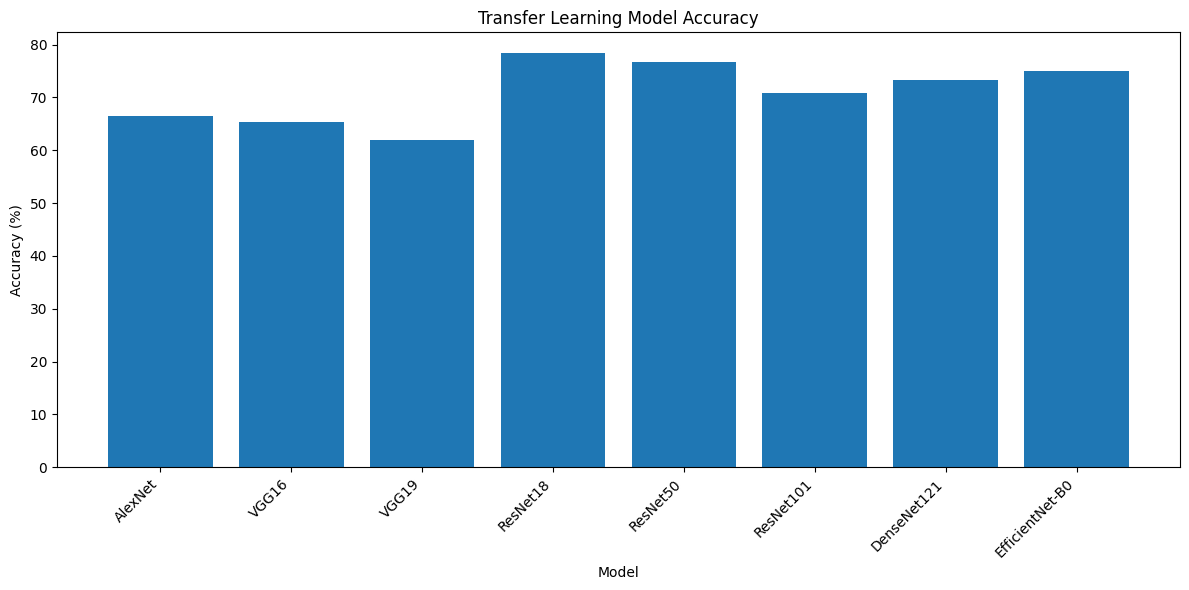

In [76]:
# Compare CNN model accuracy

plt.figure(figsize=(12, 6))

plt.bar(
    table1["Model"],
    table1["Accuracy (%)"]
)

plt.xlabel("Model")
plt.ylabel("Accuracy (%)")

plt.title(
    "Transfer Learning Model Accuracy"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

plt.show()

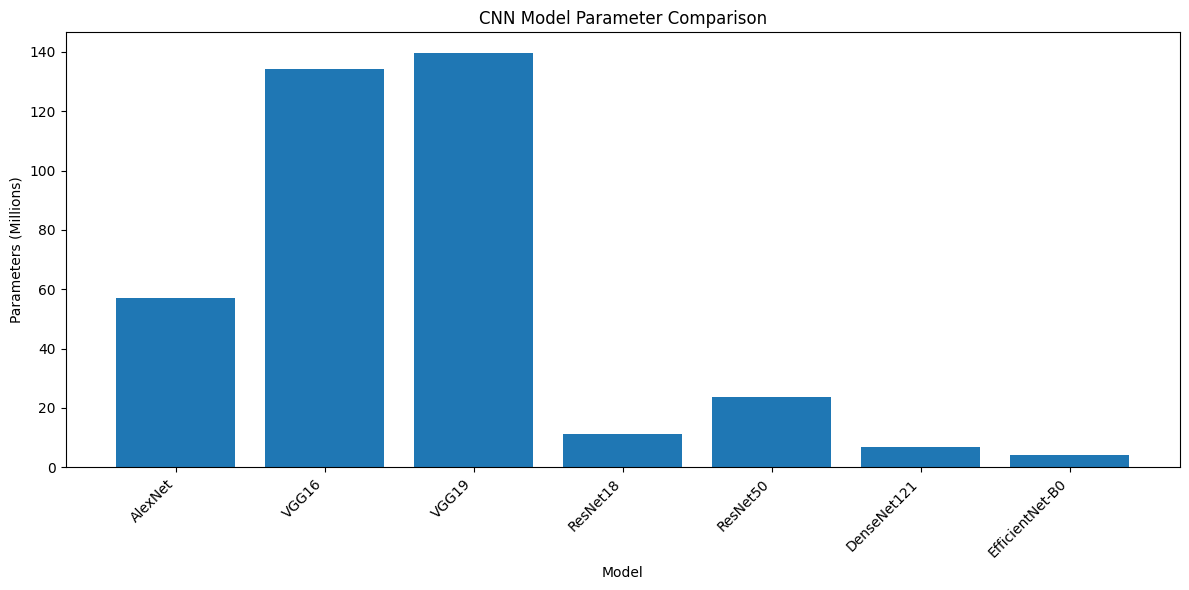

In [77]:
# Compare CNN model parameters

plt.figure(figsize=(12, 6))

plt.bar(
    table3["Model"],
    table3["Parameters (M)"]
)

plt.xlabel("Model")

plt.ylabel(
    "Parameters (Millions)"
)

plt.title(
    "CNN Model Parameter Comparison"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

plt.show()

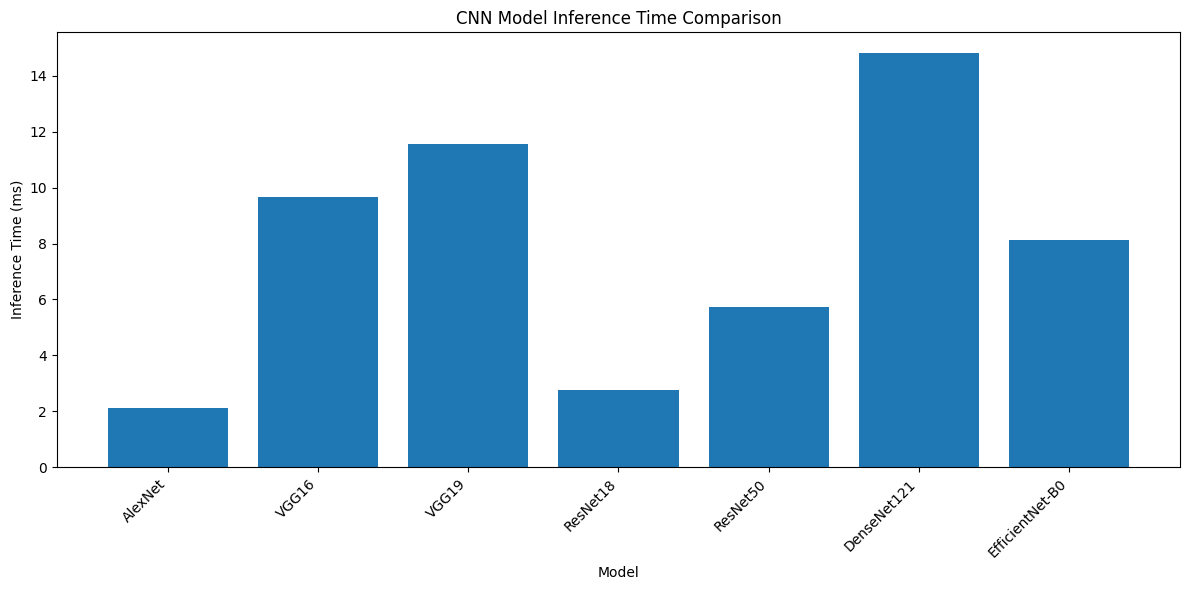

In [78]:
# Compare CNN inference time

plt.figure(figsize=(12, 6))

plt.bar(
    table3["Model"],
    table3["Inference Time (ms)"]
)

plt.xlabel("Model")

plt.ylabel(
    "Inference Time (ms)"
)

plt.title(
    "CNN Model Inference Time Comparison"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

plt.show()

In [79]:
# Create final Excel workbook

with pd.ExcelWriter(
    "Skin_Lesion_Task_Results.xlsx"
) as writer:

    table1.to_excel(
        writer,
        sheet_name="Table 1",
        index=False
    )

    table2.to_excel(
        writer,
        sheet_name="Table 2",
        index=False
    )

    table3.to_excel(
        writer,
        sheet_name="Table 3",
        index=False
    )


print(
    "Excel file created successfully."
)

Excel file created successfully.


In [80]:
# Save all trained CNN models

os.makedirs(
    "trained_models",
    exist_ok=True
)


for model_name, model in trained_models.items():

    safe_name = model_name.replace(
        "-",
        "_"
    )

    torch.save(
        model.state_dict(),
        f"trained_models/{safe_name}.pth"
    )


print(
    "All trained models saved."
)

All trained models saved.


In [81]:
# Download final Excel results

from google.colab import files

files.download(
    "Skin_Lesion_Task_Results.xlsx"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [82]:
# Download Table 1

files.download(
    "Table_1_Transfer_Learning_Results.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [83]:
# Download Table 2

files.download(
    "Table_2_Classifiers_Results.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [84]:
# Download Table 3

files.download(
    "Table_3_Computational_Efficiency.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>